# SHAP Values - Companion Notebook 4: Interpreting SHAP Values Carefully

This notebook accompanies Sections 7 and 8 of `lecture_notes/17_shap_values.pdf`.

Goals:
- distinguish local and global explanations;
- inspect classifier output scale and SHAP array shape;
- compare SHAP global importance with built-in feature importance;
- practice the main interpretation pitfalls from the notes.

The notebook avoids `xgboost` so it can run with the standard scikit-learn stack. SHAP-specific cells require the `shap` package.

In [1]:
import importlib.util
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

HAVE_SHAP = importlib.util.find_spec("shap") is not None
if HAVE_SHAP:
    import shap
else:
    print("The 'shap' package is not installed. Run `%pip install shap` to enable SHAP computations and plots.")

## 1. Train a classifier

For classifiers, always verify what output the SHAP values explain: raw scores, log-odds, probabilities, or a selected class output.

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, pred):.3f}")
print(f"ROC AUC:  {roc_auc_score(y_test, proba):.3f}")
print("classes:", clf.classes_)

accuracy: 0.951
ROC AUC:  0.993
classes: [0 1]


## 2. Built-in importance is not the same as SHAP importance

Random forests expose impurity-based feature importance. It is useful as a quick diagnostic, but the notes warn that built-in importance can behave differently from SHAP-based global importance.

In [3]:
built_in_importance = pd.Series(
    clf.feature_importances_,
    index=X.columns,
).sort_values(ascending=False)

perm = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
permutation_importance_df = pd.Series(
    perm.importances_mean,
    index=X.columns,
).sort_values(ascending=False)

pd.DataFrame(
    {
        "random_forest_importance": built_in_importance,
        "permutation_importance": permutation_importance_df,
    }
).head(12)

,random_forest_importance,permutation_importance
area error,0.024672,-0.006294
compactness error,0.002917,-0.000699
concave points error,0.003627,0.000000
concavity error,0.004451,-0.003497
fractal dimension error,0.002885,0.000000
mean area,0.035856,-0.003497
mean compactness,0.016910,-0.004895
mean concave points,0.104625,-0.002098
mean concavity,0.046609,-0.006294
mean fractal dimension,0.003283,0.000000


## 3. Compute SHAP values and inspect the output

The exact shape of `shap_values.values` may differ across SHAP versions and model configurations. Inspect it before interpreting signs and magnitudes.

In [4]:
background = X_train.sample(n=min(100, len(X_train)), random_state=42)
X_explain = X_test.iloc[:120]

if HAVE_SHAP:
    explainer = shap.Explainer(clf, background)
    shap_values = explainer(X_explain)

    print("values shape:", shap_values.values.shape)
    print("base_values shape:", np.shape(shap_values.base_values))
    print("model output names:", getattr(shap_values, "output_names", None))
else:
    shap_values = None

values shape: (120, 30, 2)
base_values shape: (120, 2)
model output names: ['Output 0', 'Output 1']


## 4. Select the positive-class explanation when needed

Some classifiers return one SHAP matrix per class. The helper below selects the explanation for class `1` when the returned explanation has a class dimension.

In [5]:
def select_class_explanation(explanation, class_index=1):
    if explanation is None:
        return None
    if explanation.values.ndim == 3:
        return explanation[:, :, class_index]
    return explanation

if HAVE_SHAP:
    shap_values_class_1 = select_class_explanation(shap_values, class_index=1)
    print("selected explanation shape:", shap_values_class_1.values.shape)

selected explanation shape: (120, 30)


## 5. Sanity check: local decomposition

A SHAP explanation should reconstruct the selected model output. For classifiers, this check is also a way to confirm which output scale is being explained.

In [6]:
if HAVE_SHAP:
    i = 0
    explanation = shap_values_class_1[i]
    reconstructed = explanation.base_values + explanation.values.sum()
    probability_class_1 = clf.predict_proba(X_explain.iloc[[i]])[0, 1]

    print(f"base value:              {float(explanation.base_values):.6f}")
    print(f"sum of SHAP values:      {float(explanation.values.sum()):.6f}")
    print(f"base + sum:              {float(reconstructed):.6f}")
    print(f"P(class 1 | x):          {probability_class_1:.6f}")
    print("If these are not close, the explainer is using a different output scale.")

base value:              0.597994
sum of SHAP values:      0.385495
base + sum:              0.983489
P(class 1 | x):          0.983468
If these are not close, the explainer is using a different output scale.


## 6. Local vs. global plots

- Waterfall: local explanation for one instance.
- Beeswarm/bar: global summaries over many instances.
- Scatter/dependence: feature behavior and possible interactions.

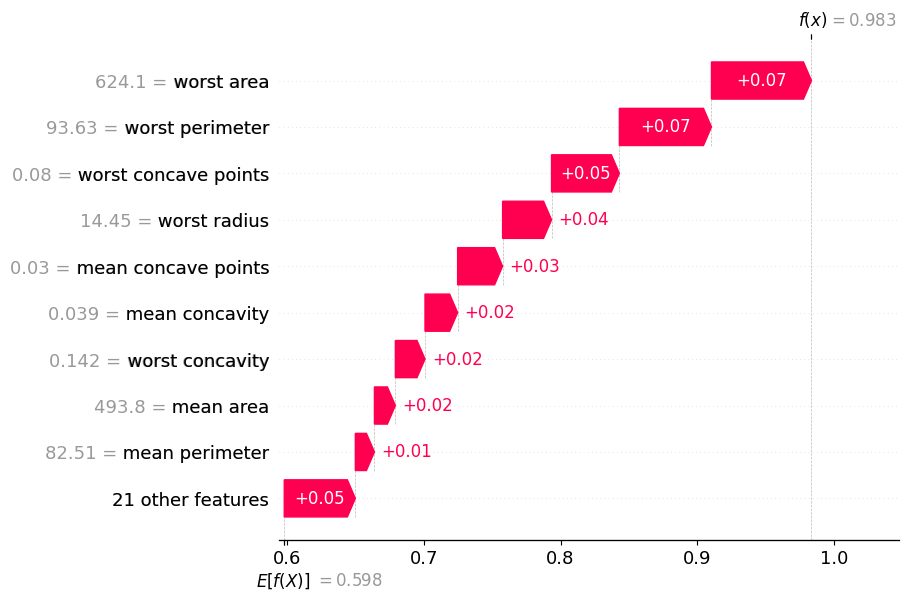

In [7]:
if HAVE_SHAP:
    shap.plots.waterfall(shap_values_class_1[0], max_display=10)

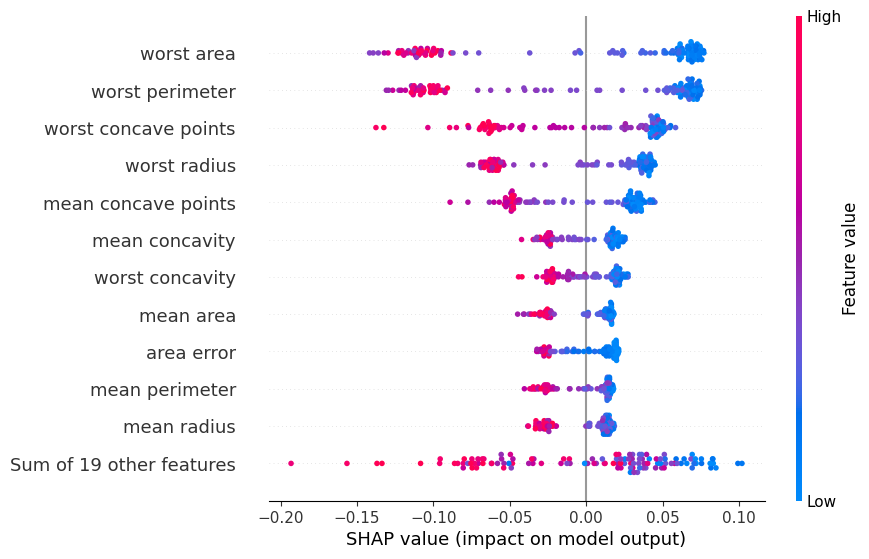

In [8]:
if HAVE_SHAP:
    shap.plots.beeswarm(shap_values_class_1, max_display=12)

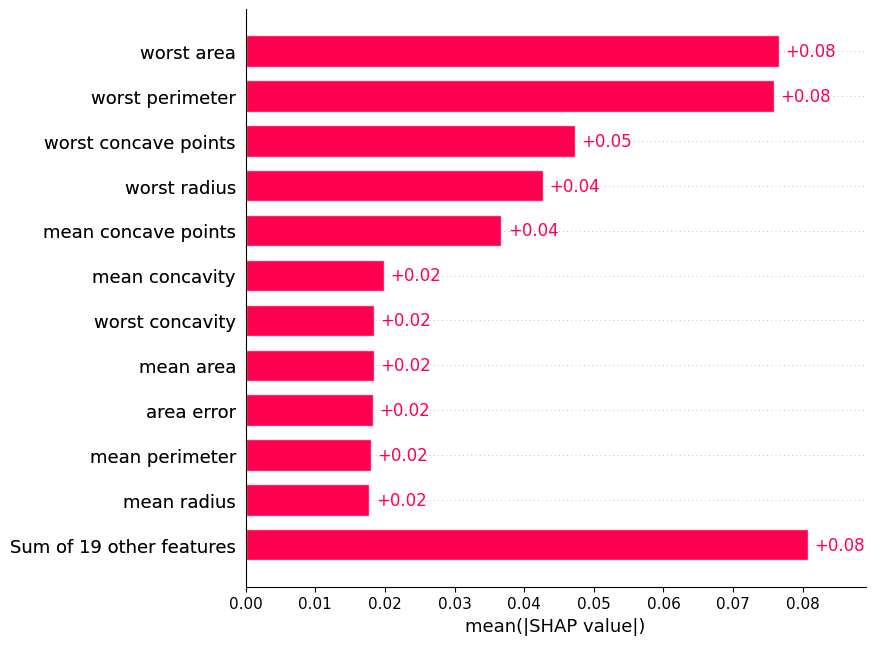

In [9]:
if HAVE_SHAP:
    shap.plots.bar(shap_values_class_1, max_display=12)

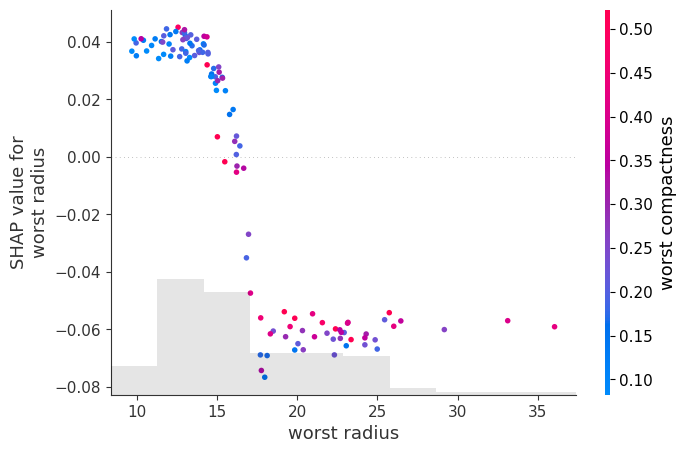

In [10]:
if HAVE_SHAP:
    shap.plots.scatter(shap_values_class_1[:, "worst radius"], color=shap_values_class_1)

## 7. Interpretation checklist

Use this checklist before trusting a SHAP interpretation:

1. What output is being explained: predicted value, probability, log-odds, or raw score?
2. What background dataset defines the baseline $\phi_0$?
3. Does $\phi_0 + \sum_i \phi_i$ reconstruct the selected model output?
4. Is the statement local or global?
5. Are correlated features splitting attribution in a way that needs grouped interpretation?
6. Are you explaining the model rather than making a causal claim about the world?